In [7]:
import pandas as pd
import matplotlib.pyplot as plt

#importing the 2025 csv ttc subway delay data as a pandas dataframe
#df_2025 = pd.read_csv('C:/Users/safab/ML7-Project/C8ML7_subwaydelay/data/raw/csv/ttc-subway-delay-data-2025.csv')
df_2025 = pd.read_csv('C:/Users/safab/ML7-Project/C8ML7_subwaydelay/data/processed/ttc_subway_delay_data_obt.csv')

#Adding a new column that is a formatted Year Column into data type Date rather than a string
df_2025['Formatted Date'] = pd.to_datetime(df_2025['date'])

#Extracted Year, Month, and Day from Date
df_2025['Year'] = df_2025['Formatted Date'].dt.year
df_2025['Month'] = df_2025['Formatted Date'].dt.month
df_2025['Day of the Month'] = df_2025['Formatted Date'].dt.day

#Formatted time from string to time and extracting hour of day
df_2025['Formatted Time'] = pd.to_datetime(df_2025['time'], format='%H:%M').dt.time
df_2025['Hour'] = pd.to_datetime(df_2025['time'], format='%H:%M').dt.hour 

#dropped preformatted columns, as well columns that are not used such as id and Bound
columns_to_drop = ['date', 'time', 'bound']

df = df_2025.drop(columns=columns_to_drop)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250292 entries, 0 to 250291
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   day                 250292 non-null  str           
 1   station             250292 non-null  str           
 2   code                250291 non-null  str           
 3   delayed_minutes     250292 non-null  int64         
 4   gap_minutes         250292 non-null  int64         
 5   line                249518 non-null  str           
 6   vehicle             250292 non-null  int64         
 7   mapped_station      250290 non-null  str           
 8   station_score       250290 non-null  float64       
 9   include_station     242250 non-null  float64       
 10  station_remarks     30899 non-null   str           
 11  delay_code          250291 non-null  str           
 12  mapped_delay_code   250291 non-null  str           
 13  fuzzy_score         250291 non-null  flo

Minute Delay Averge (grouped by month): Month
1     2.969028
2     2.779442
3     2.620029
4     2.707152
5     2.573447
6     2.530012
7     2.427158
8     2.316167
9     2.301288
10    2.471071
11    2.484695
12    2.643710
Name: delayed_minutes, dtype: float64



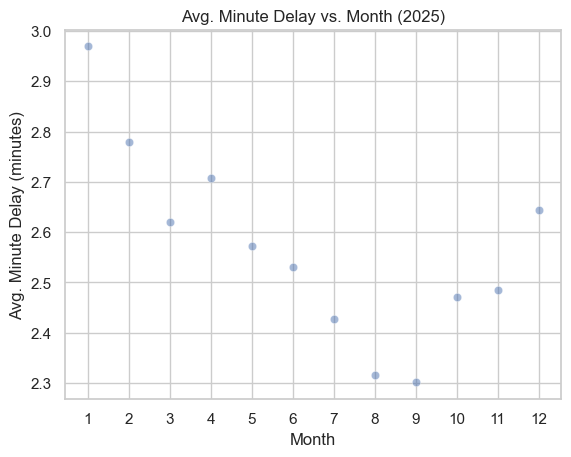

In [9]:
import seaborn as sns

# This code will aim to try and calculate the average min delay per month in 2025 and plot the results

# Set a clean visual style for plot using seaborn instead of .scatter from matplotlib
sns.set_theme(style="whitegrid")


daily_avg_groupby = df_2025.groupby(df_2025['Month'])['delayed_minutes'].mean()
print(f"Minute Delay Averge (grouped by month): {df_2025.groupby(df_2025['Month'])['delayed_minutes'].mean()}\n")
#print(f"Minute Delay Median (grouped by month): {df_2025.groupby(df_2025['Month'])['Min Delay'].median()}")

#Plotting Average Delay Time vs Month with raw uneditted data
plt.xlabel('Month')
plt.ylabel('Avg. Minute Delay (minutes)')
plt.xticks(df_2025['Month'].unique())
plt.title('Avg. Minute Delay vs. Month (2025)')
#plt.scatter((df_2025['Month'].unique()), daily_avg_groupby, s=5)
sns.scatterplot(x=df_2025['Month'].unique(), y=daily_avg_groupby, alpha=0.5)

plt.show()


Min Delay Averge (grouped by Day of week): <StringArray>
['Thursday', 'Friday', 'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday']
Length: 7, dtype: str


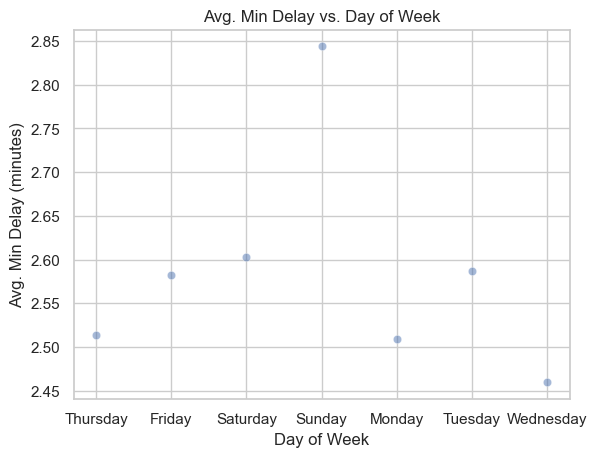

In [13]:
import seaborn as sns

# This code will aim to try and calculate the average min delay per day of the week in 2025

dayofweek_avg_groupby = df_2025.groupby(df_2025['day'])['delayed_minutes'].mean()
print(f"Min Delay Averge (grouped by Day of week): {df_2025['day'].unique()}")

# Set a clean visual style for plot using seaborn instead of .scatter from matplotlib
sns.set_theme(style="whitegrid")

#Plotting Average Delay Time vs Month with raw uneditted data
sns.scatterplot(x=df_2025['day'].unique(), y=dayofweek_avg_groupby, alpha=0.5)
plt.xlabel('Day of Week')
plt.ylabel('Avg. Min Delay (minutes)')
plt.title('Avg. Min Delay vs. Day of Week')
#plt.scatter((df_2025['Day'].unique()), dayofweek_avg_groupby, s=7)
#plt.grid(True)
plt.show()

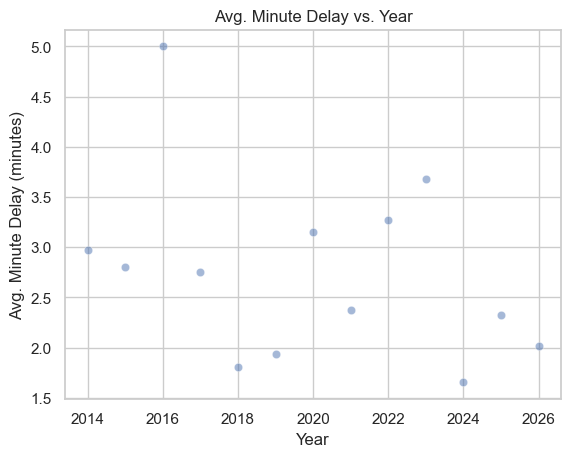

In [16]:
import seaborn as sns

# This code will aim to try and calculate the average min delay per day of the week in 2025

year_avg_groupby = df_2025.groupby(df_2025['Year'])['delayed_minutes'].mean()
#print(f"Min Delay Averge (grouped by Day of week): {df_2025['Day'].unique()}")

# Set a clean visual style for plot using seaborn instead of .scatter from matplotlib
sns.set_theme(style="whitegrid")

#Plotting Average Delay Time vs Month with raw uneditted data
sns.scatterplot(x=df_2025['Year'].unique(), y=year_avg_groupby, alpha=0.5)
plt.xlabel('Year')
plt.ylabel('Avg. Minute Delay (minutes)')
plt.title('Avg. Minute Delay vs. Year')
#plt.scatter((df_2025['Day'].unique()), dayofweek_avg_groupby, s=7)
#plt.grid(True)
plt.show()

In [18]:
#This code aims to showcase the top5 stations with the highest tot+

# Filter only rows with actual delays
delays_df = df_2025[df_2025["delayed_minutes"] > 0].copy()
#delays_df = df

# Group by station and calculate delay metrics
station_delay_summary = delays_df.groupby("mapped_station").agg(
    Total_Incidents=("delayed_minutes", "count"),
    Total_Min_Delay=("delayed_minutes", "sum"),
    Avg_Delay_Per_Incident=("delayed_minutes", "mean")
).sort_values(by="Total_Incidents", ascending=False)

#Round average delay
station_delay_summary["Avg_Delay_Per_Incident"] = station_delay_summary["Avg_Delay_Per_Incident"].round(2)

#Display top 5 stations with most delay incidents
station_delay_summary.head(5)

,Total_Incidents,Total_Min_Delay,Avg_Delay_Per_Incident
mapped_station,,,
Kennedy,4630,33660,7.27
Eglinton,4153,29289,7.05
Sheppard–Yonge,3821,29372,7.69
Finch,3610,19246,5.33
Kipling,3215,19092,5.94


Available station names (sample): ['Kennedy', 'Eglinton', 'Sheppard–Yonge', 'Finch', 'Kipling', 'St. George', 'Vaughan', 'Wilson', 'Bloor–Yonge', 'Sheppard West']


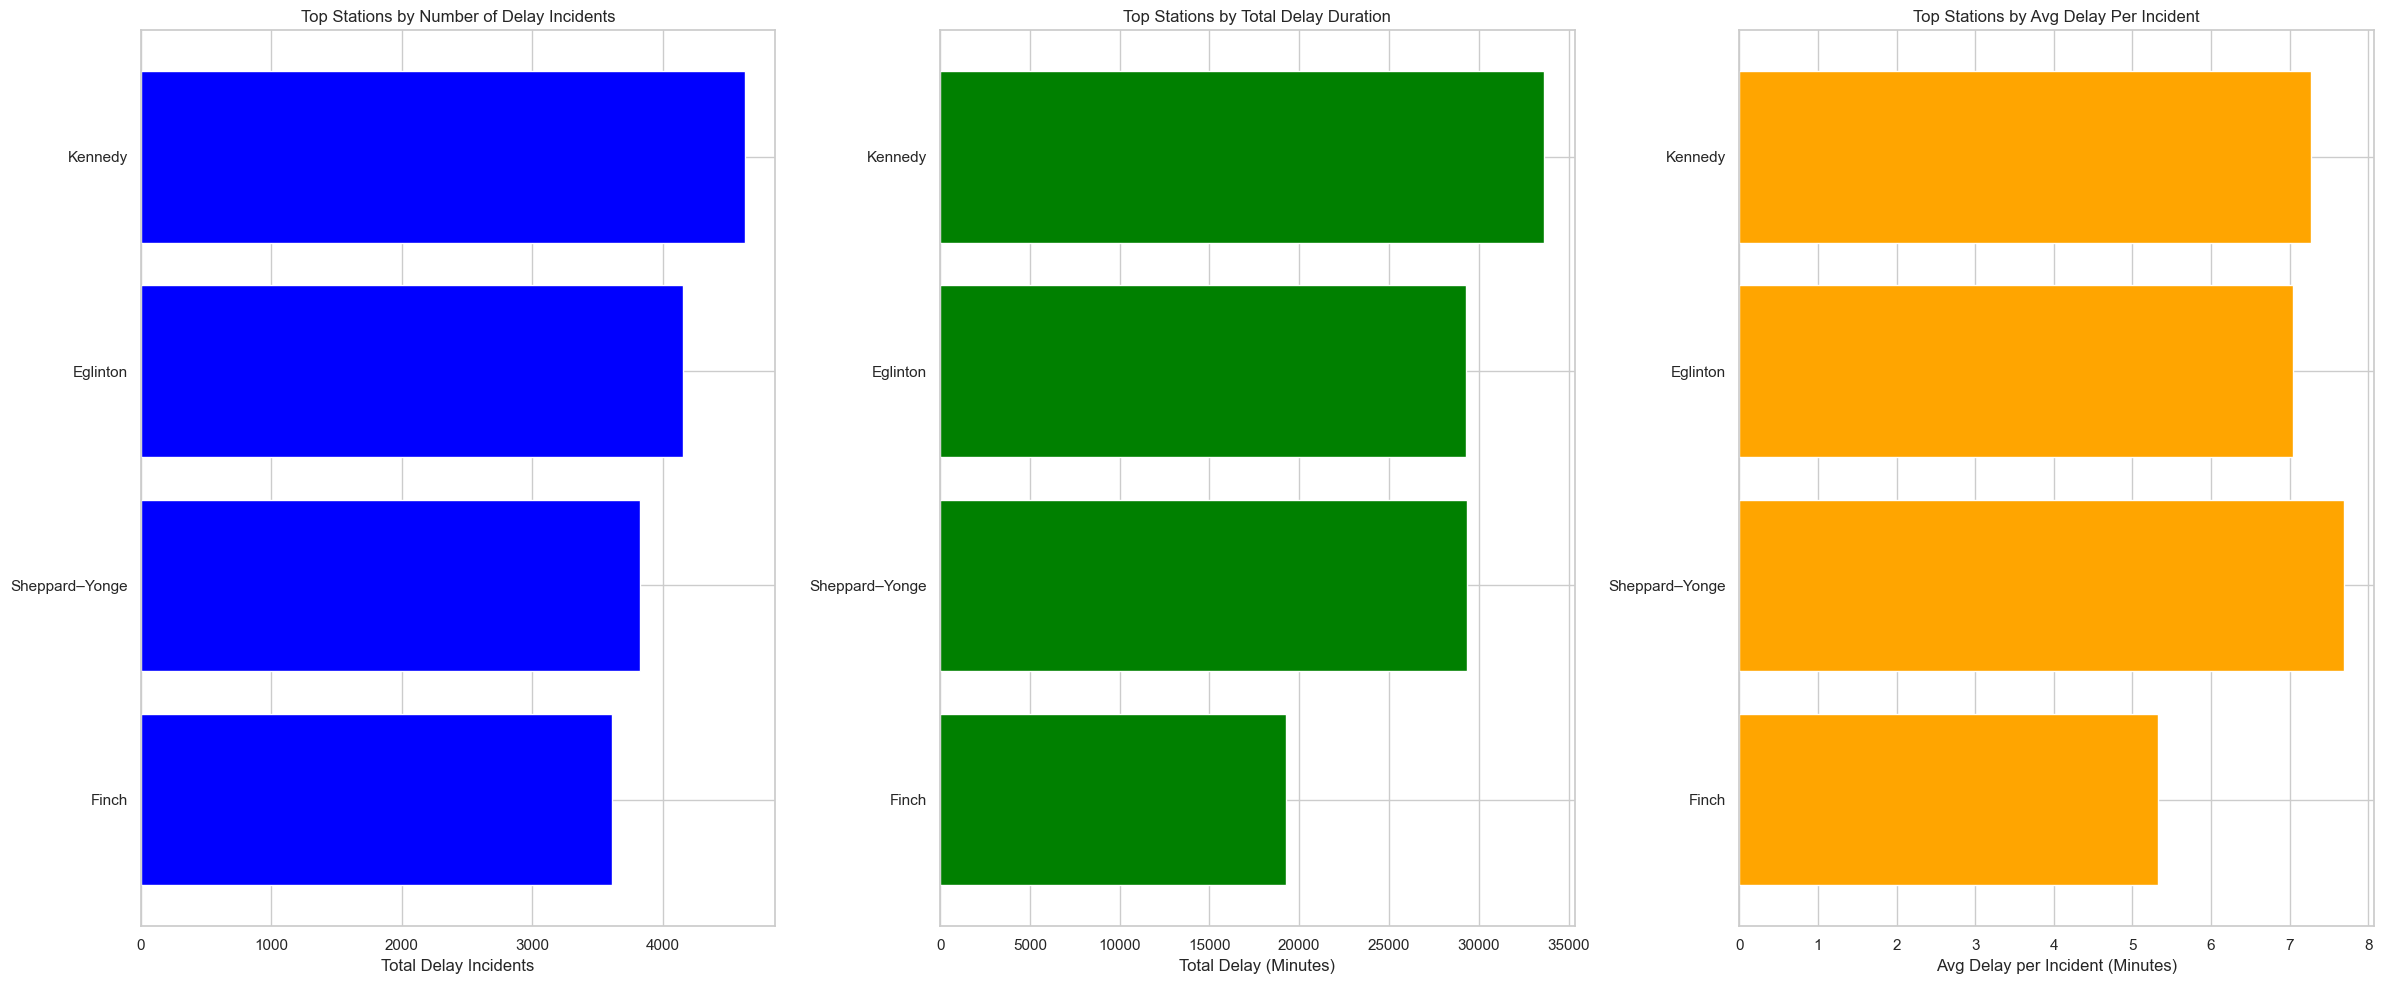

In [19]:
# Step 1: Get top 5 stations by Total_Incidents
top_stations = station_delay_summary.sort_values(by="Total_Incidents", ascending=False).head(4)

# Step 2: Check UNION STATION's presence and spelling
print("Available station names (sample):", station_delay_summary.index.tolist()[:10])  # See what's in the index


# Step 4: Plotting
fig, axes = plt.subplots(1, 3, figsize=(24, 10))
stations_reversed = top_stations.index[::-1]

# Total Incidents
axes[0].barh(stations_reversed, top_stations.loc[stations_reversed]["Total_Incidents"], color='blue')
axes[0].set_xlabel("Total Delay Incidents")
axes[0].set_title("Top Stations by Number of Delay Incidents")

# Total Delay
axes[1].barh(stations_reversed, top_stations.loc[stations_reversed]["Total_Min_Delay"], color='green')
axes[1].set_xlabel("Total Delay (Minutes)")
axes[1].set_title("Top Stations by Total Delay Duration")

# Avg Delay
axes[2].barh(stations_reversed, top_stations.loc[stations_reversed]["Avg_Delay_Per_Incident"], color='orange')
axes[2].set_xlabel("Avg Delay per Incident (Minutes)")
axes[2].set_title("Top Stations by Avg Delay Per Incident")


# Save before showing
plt.tight_layout()
plt.savefig("top_stations_with_delays.png", dpi=300, bbox_inches='tight')  # Save first
plt.show()  # Then show

This project explores and analyzes 2025 TTC subway delay data using Python. The goal is to uncover patterns in subway delays across:

 Months
 Days of the Week
 Yearly averages
Stations with the highest delay incidents

Through data grouping, aggregation, and visualization, this analysis provides insights into delay trends and high-impact locations within the Toronto subway system. We used various Python libraries such as Pandas for Data manipulation and aggregation as well as matplotlib and seaborn for data visualization and statistical plotting. The TTC delay data was loaded into a Pandas DataFrame for ease of analysis. A table below showcases the fields of the dataset:

TABLE HERE

For data exploration, we plotted the average delay by month, year and day of the week. These plots are shown below. 

PLOT HERE

SUMMARY ON FINDINGS OF PLOTS HERE

**Key Insights (Expected Outcomes)**

Certain months likely show higher delay averages (e.g., winter months).

Weekday vs weekend delay trends may differ.

A small number of stations likely contribute disproportionately to incidents.

Total incidents and total delay minutes help distinguish between:

Frequent minor delays

Fewer but severe delays